--- Starting Divergence Analysis: 18 Scenarios vs SARIMA Baseline ---


Success! Divergence chart saved at: ..\figuras\figure-diferenca-cenarios-vs-sarima-fig11.pdf

--- Divergence Summary (Annual) ---
Period: 2026-2035
SARIMA Baseline Mean (Annual): 2264.1k m³
Largest positive divergence: CVI (+25.2k m³/year)
Largest negative divergence: CII (-48.5k m³/year)


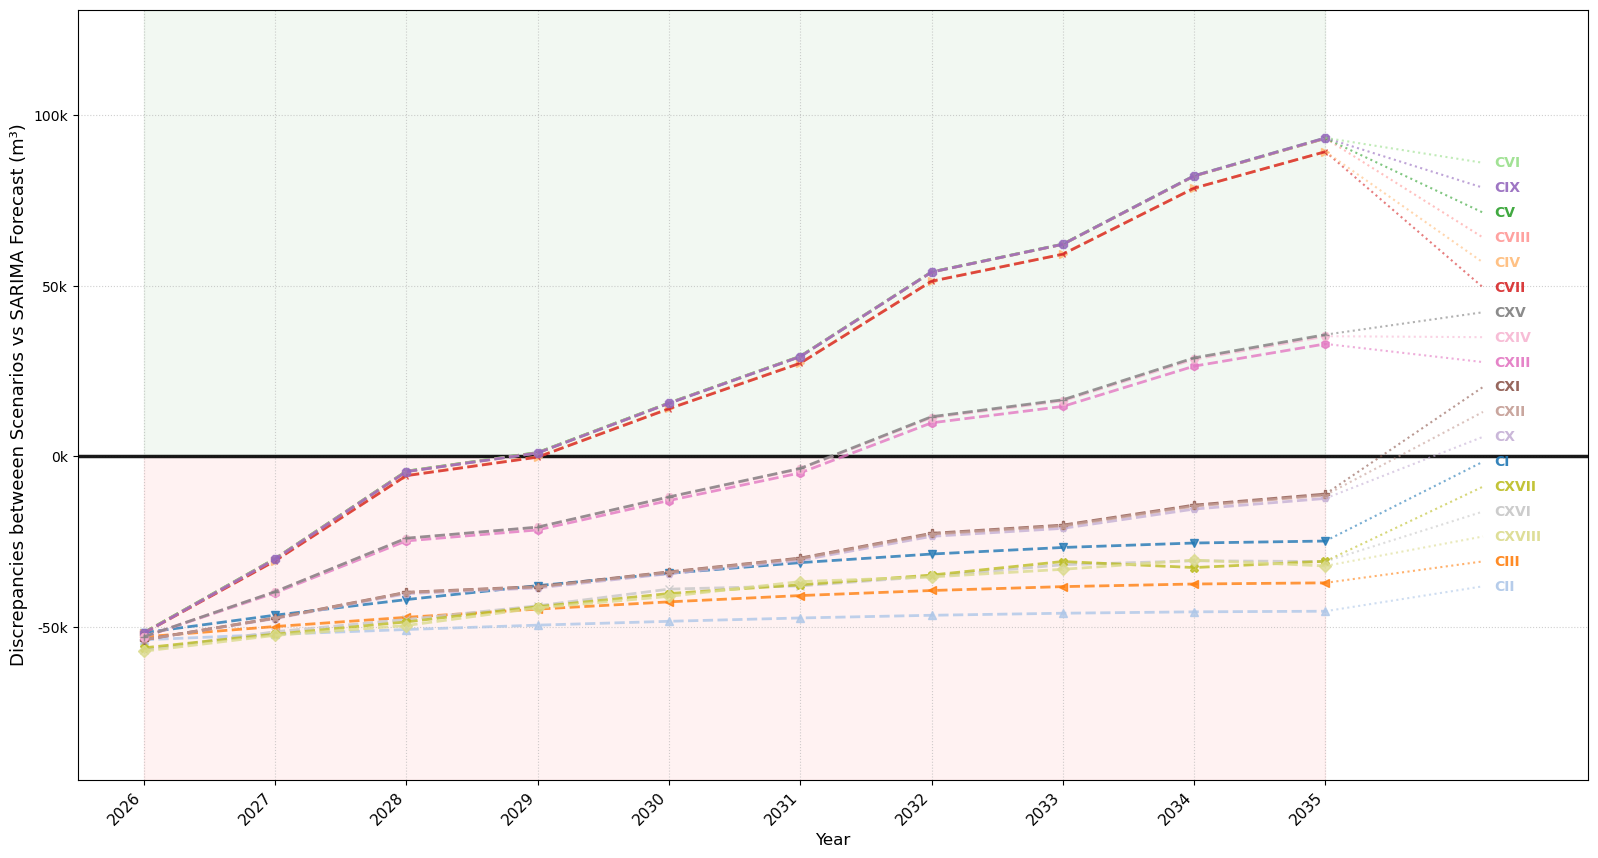

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import numpy as np
import os

# ==========================================
# 1. Configuration and Paths
# ==========================================
BASE_PATH = '..' 

np.random.seed(42)

SCENARIO_FILE = 'consumo_previsto_todos_cenarios_2026_2035.csv'
SARIMA_FILE = 'previsao_consumo_sarima_2026_2035.csv'

OUTPUT_FILENAME = 'figure-diferenca-cenarios-vs-sarima-fig11.pdf'

FIGURE_WIDTH = 20
FIGURE_HEIGHT = 10

INPUT_DIR_RES = os.path.join(BASE_PATH, 'resultados')
INPUT_DIR_MODELS = os.path.join(BASE_PATH, 'modelos IA')
INPUT_DIR_INC = os.path.join(BASE_PATH, 'includes')
OUTPUT_DIR = os.path.join(BASE_PATH, 'figuras')

def sum_yearly(df, date_col, value_cols):
    df_year = df.copy()
    df_year['Year'] = df_year[date_col].dt.year
    return df_year.groupby('Year')[value_cols].sum().reset_index()

def roman_to_value(roman):
    """Convert Roman numeral to numeric value for proper sorting"""
    roman_values = {
        'I': 1, 'II': 2, 'III': 3, 'IV': 4, 'V': 5,
        'VI': 6, 'VII': 7, 'VIII': 8, 'IX': 9, 'X': 10,
        'XI': 11, 'XII': 12, 'XIII': 13, 'XIV': 14, 'XV': 15,
        'XVI': 16, 'XVII': 17, 'XVIII': 18, 'XIX': 19, 'XX': 20
    }
    # Extract the Roman part after 'C'
    if roman.startswith('C'):
        roman_part = roman[1:]
        return roman_values.get(roman_part, 999)
    return 999

def main():
    print("--- Starting Divergence Analysis: 18 Scenarios vs SARIMA Baseline ---")

    # ==========================================
    # 2. Data Loading
    # ==========================================
    
    path_scenarios = os.path.join(INPUT_DIR_RES, SCENARIO_FILE)
    if not os.path.exists(path_scenarios):
        path_scenarios = os.path.join(INPUT_DIR_INC, SCENARIO_FILE)
    
    if not os.path.exists(path_scenarios):
        print(f"Error: Scenarios file not found: {path_scenarios}")
        return

    df_scenarios = pd.read_csv(path_scenarios, sep=';', decimal=',')
    
    if 'Mes' in df_scenarios.columns and 'Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Ano'].astype(str) + '-' + 
                                            df_scenarios['Mes'].astype(str) + '-01')
    elif 'Mes_Ano' in df_scenarios.columns:
        df_scenarios['Date'] = pd.to_datetime(df_scenarios['Mes_Ano'], format='%m/%Y')
        
    scenario_cols = [c for c in df_scenarios.columns if c not in ['Mes', 'Ano', 'Mes_Ano', 'Date']]
    df_scenarios = df_scenarios[df_scenarios['Date'] <= pd.to_datetime('2035-12-31')]

    path_sarima = os.path.join(INPUT_DIR_MODELS, SARIMA_FILE)
    if not os.path.exists(path_sarima):
        print(f"Error: SARIMA file not found: {path_sarima}")
        return
        
    df_sarima = pd.read_csv(path_sarima)
    df_sarima = df_sarima.rename(columns={'Date': 'Date', 'Projected_Consumption': 'SARIMA'})
    df_sarima['Date'] = pd.to_datetime(df_sarima['Date'])
    df_sarima = df_sarima[df_sarima['Date'] <= pd.to_datetime('2035-12-31')]

    # ==========================================
    # 3. Calculation
    # ==========================================
    
    df_combined = pd.merge(df_scenarios, df_sarima[['Date', 'SARIMA']], on='Date', how='left')
    
    all_numeric = scenario_cols + ['SARIMA']
    df_annual = sum_yearly(df_combined, 'Date', all_numeric)
    
    # short_names of scenarios
    short_names = {col: (col.split('_')[0] if '_' in col else col) for col in all_numeric}
    df_annual = df_annual.rename(columns=short_names)
    
    
    scenario_cols_short = [short_names[col] for col in scenario_cols]
    
    diff_cols = []
    for col in scenario_cols_short:
        diff_col_name = f"Diff_{col}"
        df_annual[diff_col_name] = df_annual[col] - df_annual['SARIMA']
        diff_cols.append(diff_col_name)

    scenario_period = f"{df_annual['Year'].min()}-{df_annual['Year'].max()}"

    # ==========================================
    # 4. Plotting
    # ==========================================
    
    fig, ax = plt.subplots(figsize=(FIGURE_WIDTH, FIGURE_HEIGHT))
    
    ax.axhline(y=0, color='black', linestyle='-', linewidth=2.5, alpha=0.9, label='SARIMA Baseline')

    markers_list = ['v', '^', '<', '>', '1', '2', '3', '4', '8', 'p', 'P', '*', 'h', 'H', '+', 'x', 'X', 'D']
    
    # order scenarios alpha
    scenario_order = sorted(scenario_cols_short, key=roman_to_value)
    diff_cols_ordered = [f"Diff_{col}" for col in scenario_order]
    
    # color generation
    tab20_colors = [plt.cm.tab20(i) for i in range(20)]  # fixed list of 20 colors
    color_map = {scenario: tab20_colors[i % 20] for i, scenario in enumerate(scenario_order)}

    for idx, col in enumerate(diff_cols_ordered):
        original_name = col.replace("Diff_", "")
        scenario_id = original_name
        
        ax.plot(df_annual['Year'], df_annual[col],
                color=color_map[original_name],
                linestyle='--',
                linewidth=2.0,
                alpha=0.8,
                marker=markers_list[idx % len(markers_list)],
                markersize=6,
                label=scenario_id)

    # ==========================================
    # 5. Add Labels at the End of Lines
    # ==========================================
    
    scenario_final_values = []
    for idx, col in enumerate(diff_cols_ordered):
        original_name = col.replace("Diff_", "")
        scenario_id = original_name
        last_value = df_annual[col].iloc[-1]
        scenario_final_values.append((scenario_id, last_value, idx, col))
    
    scenario_final_values.sort(key=lambda x: x[1])
    
    all_final_values = [v[1] for v in scenario_final_values]
    y_min_final = min(all_final_values)
    y_max_final = max(all_final_values)
    y_range_final = y_max_final - y_min_final
    vertical_spacing = y_range_final / (len(scenario_final_values) + 1) if y_range_final > 0 else 1000
    
    last_year = df_annual['Year'].iloc[-1]
    extended_x = last_year + 1.2
    
    for position, (scenario_id, last_value, original_idx, col) in enumerate(scenario_final_values):
        if len(scenario_final_values) > 1 and y_range_final > 0:
            y_label_pos = y_min_final + (position + 1) * vertical_spacing
        else:
            y_label_pos = last_value
        
        ax.plot([last_year, extended_x], [last_value, y_label_pos], 
                color=color_map[scenario_id], linestyle=':', linewidth=1.5, alpha=0.6, zorder=15)
        
        ax.annotate(scenario_id, 
                   xy=(extended_x, y_label_pos),
                   xytext=(8, 0),
                   textcoords="offset points",
                   fontsize=10,
                   color=color_map[scenario_id],
                   fontweight='bold',
                   alpha=0.9,
                   zorder=25,
                   va='center')

    # ==========================================
    # 6. Formatting and Export
    # ==========================================
    
    ax.set_xticks(df_annual['Year'])
    ax.set_xlabel('Year', fontsize=12)
    ax.set_xticklabels(df_annual['Year'], rotation=45, ha='right', fontsize=11)
    
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x/1000:.0f}k'))
    
    y_min_all = min(df_annual[diff_cols_ordered].min())
    y_max_all = max(df_annual[diff_cols_ordered].max())
    y_range = y_max_all - y_min_all
    y_margin = y_range * 0.25 if y_range > 0 else 5000
    
    ax.set_xlim(df_annual['Year'].min() - 0.5, df_annual['Year'].max() + 2.0)
    ax.set_ylim(y_min_all - y_margin, y_max_all + y_margin)
    ax.set_ylabel('Discrepancies betweeen Scenarios vs SARIMA Forecast (m³)', fontsize=13)
    
    plt.grid(True, linestyle=':', alpha=0.6)
    
    ax.fill_between(df_annual['Year'], 0, y_max_all + y_margin, 
                    alpha=0.05, color='green', label='_nolegend_')
    ax.fill_between(df_annual['Year'], y_min_all - y_margin, 0, 
                    alpha=0.05, color='red', label='_nolegend_')
    
    plt.subplots_adjust(bottom=0.18, top=0.95, right=0.88)
    
    if not os.path.exists(OUTPUT_DIR): 
        os.makedirs(OUTPUT_DIR)
    full_output_path = os.path.join(OUTPUT_DIR, OUTPUT_FILENAME)
        
    plt.savefig(full_output_path, format='pdf', bbox_inches='tight', dpi=300)
    
    print(f"Success! Divergence chart saved at: {full_output_path}")
    
    print("\n--- Divergence Summary (Annual) ---")
    print(f"Period: {scenario_period}")
    print(f"SARIMA Baseline Mean (Annual): {df_annual['SARIMA'].mean()/1000:.1f}k m³")
    
    max_div_scenario = None
    max_div_value = -float('inf')
    min_div_scenario = None
    min_div_value = float('inf')
    
    for col in diff_cols_ordered:
        scenario_id = col.replace("Diff_", "")
        avg_div = df_annual[col].mean()
        if avg_div > max_div_value:
            max_div_value = avg_div
            max_div_scenario = scenario_id
        if avg_div < min_div_value:
            min_div_value = avg_div
            min_div_scenario = scenario_id
    
    print(f"Largest positive divergence: {max_div_scenario} (+{max_div_value/1000:.1f}k m³/year)")
    print(f"Largest negative divergence: {min_div_scenario} ({min_div_value/1000:.1f}k m³/year)")
        
    plt.show()

if __name__ == "__main__":
    main()